In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf 

## data load in

In [11]:
path = "Data/gas_coordinates.csv"
gas = pd.read_csv(path)
gas.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223


In [12]:
path = "Data/ignore/hurr_data.csv"
hurricanes = pd.read_csv(path)
hurricanes.head()

,name,nature,date,lat,lon,wmo_wind,dist2land,landfall,usa_sshs,storm_speed,usa_roci
0,ANA,ET,2021-05-20,30.3,-55.5,30.0,1675,1669.0,-4,13.0,150.0
1,ANA,ET,2021-05-20,30.9,-55.1,NaN,1664,1628.0,-4,15.0,150.0
2,ANA,ET,2021-05-20,31.5,-54.5,35.0,1628,1580.0,-4,19.0,150.0
3,ANA,ET,2021-05-20,32.3,-53.6,NaN,1574,1513.0,-4,20.0,150.0
4,ANA,ET,2021-05-20,33.0,-53.0,40.0,1513,1446.0,-4,15.0,150.0


In [13]:
metros = gas[["metro", "lat", "lng"]].drop_duplicates()
metros.head()

,metro,lat,lng
0,Bradenton-Sarasota-Venice,27.3479,-82.3223
1440,Crestview-Fort Walton Beach,30.6657,-86.3657
2880,Daytona Beach,29.1740,-81.2197
4320,Fort Lauderdale,26.1573,-80.5059
5760,Fort Myers-Cape Coral,26.5780,-81.8332


Text(0.5, 1.0, 'Hurricane paths over Florida')

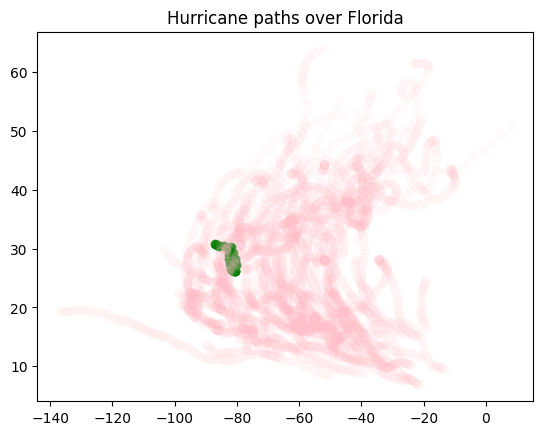

In [14]:
plt.scatter(metros["lng"], metros["lat"], color = "green")
plt.scatter(hurricanes["lon"], hurricanes["lat"], alpha=0.05, color = "pink")
plt.title("Hurricane paths over Florida")

## combining 

In [15]:
miami_lat = 25.7617
miami_lng = -80.1918

In [16]:
gas['date'].dtype == hurricanes['date'].dtype

True

distance with euclidean measure

In [17]:
hurricanes = hurricanes.dropna(subset = ["wmo_wind"])

hurricanes = hurricanes.drop_duplicates(subset = "date", keep = "first")

In [18]:
hurricanes.shape

(367, 11)

In [19]:
gas.shape

(34560, 10)

In [20]:
panel = gas.merge(hurricanes, on = "date", how = "left")
panel.shape

(34560, 20)

In [21]:
hurricanes.head()

,name,nature,date,lat,lon,wmo_wind,dist2land,landfall,usa_sshs,storm_speed,usa_roci
0,ANA,ET,2021-05-20,30.3,-55.5,30.0,1675,1669.0,-4,13.0,150.0
8,ANA,ET,2021-05-21,34.8,-55.0,50.0,1267,1196.0,-4,15.0,150.0
16,ANA,ET,2021-05-22,34.5,-61.8,40.0,1046,1046.0,-4,5.0,200.0
24,ANA,TS,2021-05-23,34.7,-61.8,40.0,1024,1000.0,0,8.0,260.0
32,ANA,DS,2021-05-24,37.6,-56.7,35.0,920,NaN,-3,18.0,60.0


In [22]:
gas.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat,lng
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223


In [23]:
panel.head()

,metro,date,regular,mid,premium,diesel,reg_delt,met,lat_x,lng,name,nature,lat_y,lon,wmo_wind,dist2land,landfall,usa_sshs,storm_speed,usa_roci
0,Bradenton-Sarasota-Venice,2022-01-21,3.236000,3.625,3.915000,3.563000,NaN,North Port-Bradenton-Sarasota,27.3479,-82.3223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Bradenton-Sarasota-Venice,2022-01-22,3.254667,3.639,3.929667,3.587667,0.576844,North Port-Bradenton-Sarasota,27.3479,-82.3223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Bradenton-Sarasota-Venice,2022-01-23,3.273333,3.653,3.944333,3.612333,0.573535,North Port-Bradenton-Sarasota,27.3479,-82.3223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Bradenton-Sarasota-Venice,2022-01-24,3.292000,3.667,3.959000,3.637000,0.570265,North Port-Bradenton-Sarasota,27.3479,-82.3223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Bradenton-Sarasota-Venice,2022-01-25,3.310667,3.681,3.973667,3.661667,0.567031,North Port-Bradenton-Sarasota,27.3479,-82.3223,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
print("gas:", gas.shape)
print("hurricanes:", hurricanes.shape)

panel = gas.merge(hurricanes, on="date", how="left")
print("panel:", panel.shape)

print(panel[["date", "met", "lat_x", "lng", "lat_y", "lon"]].head(10))

gas: (34560, 10)
hurricanes: (367, 11)
panel: (34560, 20)
         date                            met    lat_x      lng  lat_y  lon
0  2022-01-21  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
1  2022-01-22  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
2  2022-01-23  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
3  2022-01-24  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
4  2022-01-25  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
5  2022-01-26  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
6  2022-01-27  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
7  2022-01-28  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
8  2022-01-29  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN
9  2022-01-30  North Port-Bradenton-Sarasota  27.3479 -82.3223    NaN  NaN


In [25]:
panel["distance"] = np.sqrt(
    (panel["lat_x"] - panel['lat_y'])**2 + 
    (panel["lng"] - panel['lon'])**2
)

In [26]:
panel.to_csv("panel_data.csv", index = False)

## Simple regression

In [27]:
reg1 = smf.ols("regular ~ distance", data = panel).fit()
print(reg1.summary())

                            OLS Regression Results                            
Dep. Variable:                regular   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     64.05
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.43e-15
Time:                        04:03:44   Log-Likelihood:                -2788.0
No. Observations:                6312   AIC:                             5580.
Df Residuals:                    6310   BIC:                             5593.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4316      0.009    384.315      0.0

In [28]:
reg2 = smf.ols("regular ~ distance + C(met)", data = panel).fit()
print(reg2.summary())

                            OLS Regression Results                            
Dep. Variable:                regular   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     13.95
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           1.20e-50
Time:                        04:03:44   Log-Likelihood:                -2669.5
No. Observations:                6312   AIC:                             5385.
Df Residuals:                    6289   BIC:                             5540.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [29]:
reg3 = smf.ols("regular ~ distance + C(met) + C(date)", data = panel).fit()
print(reg3.summary())

                            OLS Regression Results                            
Dep. Variable:                regular   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1444.
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:03:46   Log-Likelihood:                 10545.
No. Observations:                6312   AIC:                        -2.052e+04
Df Residuals:                    6027   BIC:                        -1.860e+04
Df Model:                         284                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------

In [30]:
panel["log_price"] = np.log(panel["regular"])

reg_log_linear = smf.ols("log_price ~ distance", data = panel).fit()

print(reg_log_linear.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     66.43
Date:                Thu, 26 Mar 2026   Prob (F-statistic):           4.34e-16
Time:                        04:03:47   Log-Likelihood:                 5572.8
No. Observations:                6312   AIC:                        -1.114e+04
Df Residuals:                    6310   BIC:                        -1.113e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.2262      0.002    516.426      0.0

## MLR

In [31]:
reg_delt = smf.ols("reg_delt ~ distance + dist2land + storm_speed + C(date)", data = panel).fit()

print(reg_delt.summary())

                            OLS Regression Results                            
Dep. Variable:               reg_delt   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     77.11
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:03:48   Log-Likelihood:                -239.59
No. Observations:                6312   AIC:                             1007.
Df Residuals:                    6048   BIC:                             2789.
Df Model:                         263                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.15

## interaction term => synnergetic effect

In [32]:
reg_int = smf.ols("regular ~ distance * C(met) + C(date)", data = panel).fit()
print(reg_int.summary())

                            OLS Regression Results                            
Dep. Variable:                regular   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1426.
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        04:03:51   Log-Likelihood:                 10739.
No. Observations:                6312   AIC:                        -2.087e+04
Df Residuals:                    6006   BIC:                        -1.880e+04
Df Model:                         305                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------